In [4]:
#import all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [5]:
df = pd.read_csv('Health_Resource_Allocation_Dataset.csv')
print("first five rows of the dataset")
print(df.head())
print('-'*50)


first five rows of the dataset
  District    Region Population  Health_Facilities Doctors  Nurses  \
0    Jinja  Northern     464002                 11      23     568   
1   Masaka  Northern      89317                 16     116     448   
2  Kampala   Central     284083                 79      20     426   
3     Gulu   Western     489499                 23     143     140   
4   Kabale  Northern     440487                 17     145      84   

  Hospital_Beds  Disease_Cases  Medicine_Stock  Emergency_Visits  \
0           116          24465            77.0              1050   
1            91          16272            45.0              9128   
2            70          14988            42.0              9220   
3           604          20716            75.0              3061   
4           597           4406            79.0              3474   

  Budget_Million_UGX Resource_Need_Level  
0               7652              Medium  
1               3677              Medium  
2         

In [14]:
print("Information about the dataset")
df.info()
print('-'*50)
print("Statistical summary of the dataset")
df.describe()

Information about the dataset
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   District             1500 non-null   str    
 1   Region               1500 non-null   str    
 2   Population           1500 non-null   str    
 3   Health_Facilities    1500 non-null   int64  
 4   Doctors              1499 non-null   str    
 5   Nurses               1500 non-null   int64  
 6   Hospital_Beds        1500 non-null   str    
 7   Disease_Cases        1500 non-null   int64  
 8   Medicine_Stock       1499 non-null   float64
 9   Emergency_Visits     1500 non-null   int64  
 10  Budget_Million_UGX   1499 non-null   str    
 11  Resource_Need_Level  1500 non-null   str    
dtypes: float64(1), int64(4), str(7)
memory usage: 140.8 KB
--------------------------------------------------
Statistical summary of the dataset


,Health_Facilities,Nurses,Disease_Cases,Medicine_Stock,Emergency_Visits
count,1500.000000,1500.000000,1500.000000,1499.000000,1500.000000
mean,41.668000,309.304667,25262.232667,70.130087,5015.640667
std,21.663825,169.039475,14125.409750,17.339569,2912.121972
min,5.000000,20.000000,562.000000,40.000000,102.000000
25%,23.000000,163.000000,13430.750000,56.000000,2439.000000
50%,40.000000,296.500000,24658.000000,70.000000,5040.500000
75%,60.000000,457.250000,37307.750000,85.000000,7621.750000
max,80.000000,600.000000,49960.000000,150.000000,9996.000000


In [20]:
numerical_columns = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX']

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

C:\Users\LINET\AppData\Local\Temp\ipykernel_18124\941793386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')


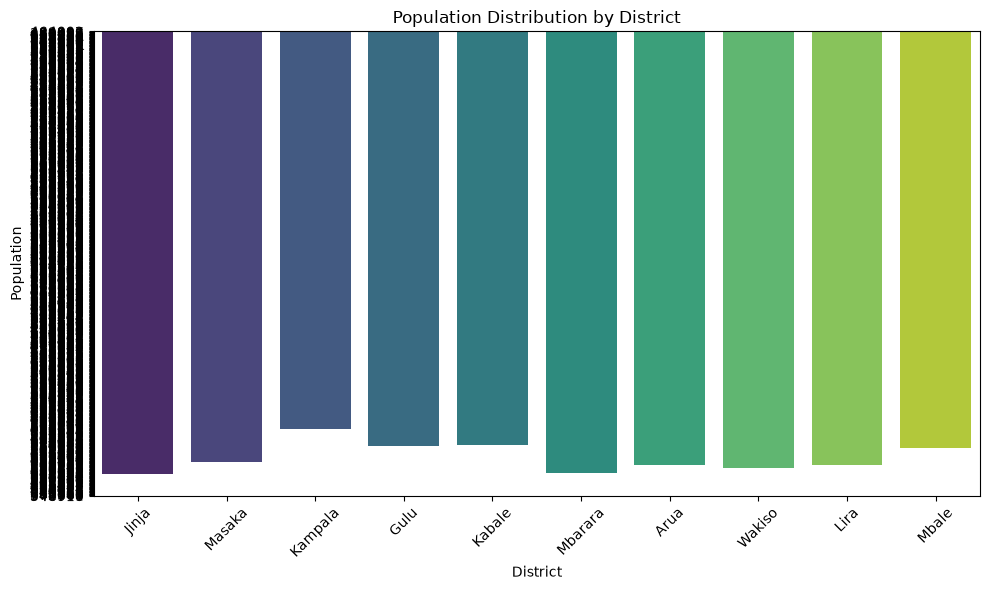

In [6]:
#A barplot for districts against population
plt.figure(figsize=(10, 6))
sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')
plt.title('Population Distribution by District')
plt.xlabel('District')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
#STEP 3: Some columns LOOK numeric but are stored as text (object/str)
# This happens when a column has stray text mixed in, e.g. "520K" instead of 520000
# Let's check which ones
for col in ["Population", "Doctors", "Hospital_Beds", "Budget_Million_UGX"]:
    print(col, "->", df[col].dtype)

Population -> str
Doctors -> str
Hospital_Beds -> str
Budget_Million_UGX -> str


In [8]:
# STEP 5: Value counts for categorical columns
# This answers "how many of each category do I have?"
print(df["Region"].value_counts())
print()
print(df["Resource_Need_Level"].value_counts())

Region
Central     403
Northern    396
Western     351
Eastern     350
Name: count, dtype: int64

Resource_Need_Level
High      667
Medium    514
Low       319
Name: count, dtype: int64


In [9]:
# STEP 6: Group and compare
# groupby() is like a pivot table: "for each Region, what's the average Disease_Cases?"
df.groupby("Region")["Disease_Cases"].mean()

Region
Central     24640.374690
Eastern     26313.414286
Northern    25477.022727
Western     24685.703704
Name: Disease_Cases, dtype: float64

In [10]:
# Try grouping by Resource_Need_Level instead, across a few columns at once
df.groupby("Resource_Need_Level")[["Doctors", "Nurses", "Hospital_Beds", "Budget_Million_UGX"]].mean(numeric_only=True)

,Nurses
Resource_Need_Level,
High,303.703148
Low,319.670846
Medium,310.140078


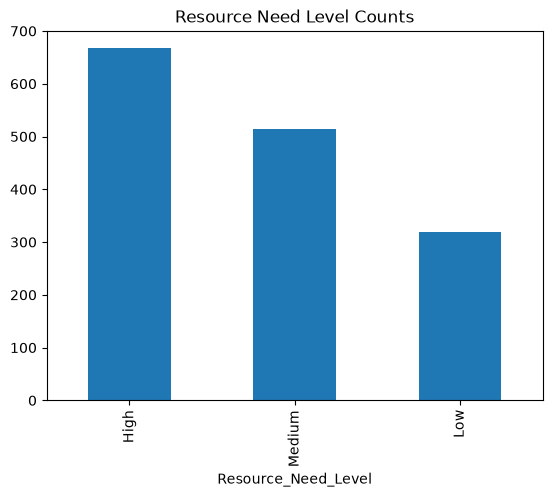

In [11]:
import matplotlib.pyplot as plt
 
df["Resource_Need_Level"].value_counts().plot(kind="bar", title="Resource Need Level Counts")
plt.show()

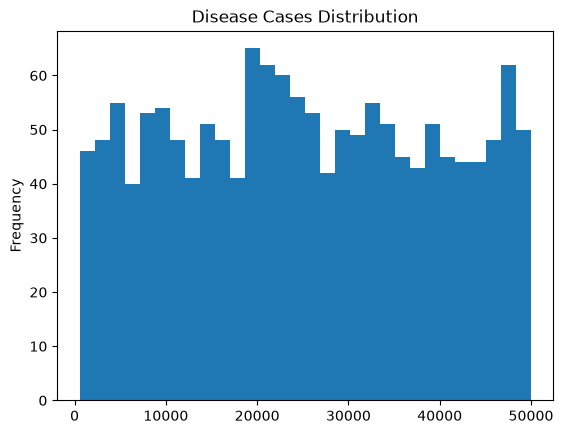

In [12]:
#Try your own: plot a histogram of Disease_Cases
df["Disease_Cases"].plot(kind="hist", bins=30, title="Disease Cases Distribution")
plt.show()